## Data Load

In [65]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/selly/Desktop/부트캠프/미션/미션 4/data/health_info.csv", encoding='cp949')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df.head()

,기준년도,가입자일련번호,시도코드,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
0,2022,702763,41,2,14,160,75,89.0,1.0,1.0,1.0,1.0,127.0,73.0,84.0,NaN,NaN,NaN,NaN,14.8,1.0,0.8,25.0,20.0,15.0,1.0,0.0,0,NaN,NaN
1,2022,765435,41,2,9,150,45,68.0,1.0,1.0,1.0,1.0,127.0,75.0,85.0,NaN,NaN,NaN,NaN,13.1,1.0,0.8,19.0,10.0,7.0,1.0,1.0,0,NaN,NaN
2,2022,343621,41,2,13,150,60,78.8,1.0,1.0,1.0,1.0,135.0,81.0,105.0,NaN,NaN,NaN,NaN,13.0,1.0,0.8,17.0,15.0,15.0,1.0,1.0,0,NaN,NaN
3,2022,3393534,41,2,6,160,50,69.0,1.0,1.0,1.0,1.0,109.0,70.0,81.0,NaN,NaN,NaN,NaN,13.4,1.0,0.8,25.0,16.0,13.0,1.0,1.0,0,NaN,NaN
4,2022,1716951,41,2,7,160,55,75.0,1.0,1.0,1.0,1.0,110.0,67.0,79.0,NaN,NaN,NaN,NaN,14.7,1.0,0.8,22.0,22.0,15.0,1.0,1.0,0,NaN,NaN


- 원본 데이터의 수가 너무 많아서 랜덤하게 10만개만 샘플링하여서 진행

In [66]:
df = df.sample(n=100000, random_state=42).reset_index(drop=True)

## Data EDA

In [67]:
print(df.shape) # 10만개의 행과 30개의 열로 이루어진 데이터

(100000, 30)


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   기준년도         100000 non-null  int64  
 1   가입자일련번호      100000 non-null  int64  
 2   시도코드         100000 non-null  int64  
 3   성별           100000 non-null  int64  
 4   연령대코드(5세단위)  100000 non-null  int64  
 5   신장(5cm단위)    100000 non-null  int64  
 6   체중(5kg단위)    100000 non-null  int64  
 7   허리둘레         99961 non-null   float64
 8   시력(좌)        99986 non-null   float64
 9   시력(우)        99986 non-null   float64
 10  청력(좌)        99989 non-null   float64
 11  청력(우)        99989 non-null   float64
 12  수축기혈압        99442 non-null   float64
 13  이완기혈압        99442 non-null   float64
 14  식전혈당(공복혈당)   99436 non-null   float64
 15  총콜레스테롤       34482 non-null   float64
 16  트리글리세라이드     34482 non-null   float64
 17  HDL콜레스테롤     34482 non-null   float64
 18  LDL콜레스테롤     33795 non-nu

In [69]:
df.describe()

,기준년도,가입자일련번호,시도코드,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
count,100000.0,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99961.000000,99986.000000,99986.000000,99989.000000,99989.000000,99442.000000,99442.000000,99436.000000,34482.000000,34482.000000,34482.000000,33795.000000,99437.000000,98870.000000,99436.000000,99436.000000,99436.000000,99436.000000,99984.000000,99990.000000,100000.000000,34439.000000,34439.000000
mean,2022.0,2.491835e+06,33.777310,1.483040,10.554950,162.646650,64.363950,81.472563,0.958237,0.955008,1.034884,1.033574,123.178094,75.787363,101.058399,197.755090,131.615191,56.886755,115.385087,14.220338,1.130909,0.837475,27.094553,26.809596,36.173177,1.548788,0.654705,0.344390,0.172247,0.564331
std,0.0,1.442941e+06,12.560765,0.499715,3.033719,9.387725,13.806596,11.343488,0.570798,0.544925,0.194030,0.189650,14.663931,10.290349,23.801722,43.908122,101.305776,15.435684,40.010298,1.545795,0.492575,0.332433,25.328683,30.198904,68.469187,0.793554,0.475467,0.475171,0.377600,0.576895
min,2022.0,1.800000e+01,11.000000,1.000000,5.000000,130.000000,30.000000,49.000000,0.100000,0.100000,1.000000,1.000000,72.000000,31.000000,44.000000,42.000000,6.000000,5.000000,3.000000,4.000000,1.000000,0.050000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.0,1.241929e+06,27.000000,1.000000,8.000000,155.000000,55.000000,74.000000,0.700000,0.700000,1.000000,1.000000,113.000000,69.000000,89.000000,169.000000,74.000000,46.000000,89.000000,13.200000,1.000000,0.700000,19.000000,15.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2022.0,2.481118e+06,41.000000,1.000000,11.000000,165.000000,65.000000,81.000000,1.000000,1.000000,1.000000,1.000000,122.000000,76.000000,96.000000,196.000000,107.000000,55.000000,114.000000,14.200000,1.000000,0.800000,23.000000,21.000000,23.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,2022.0,3.740472e+06,43.000000,2.000000,13.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,132.000000,82.000000,106.000000,225.000000,156.000000,66.000000,140.000000,15.300000,1.000000,1.000000,30.000000,31.000000,38.000000,2.000000,1.000000,1.000000,0.000000,1.000000
max,2022.0,4.999859e+06,49.000000,2.000000,18.000000,195.000000,135.000000,999.000000,9.900000,9.900000,3.000000,3.000000,255.000000,160.000000,649.000000,1823.000000,2676.000000,871.000000,1788.000000,25.000000,6.000000,25.000000,3753.000000,4390.000000,9999.000000,3.000000,1.000000,1.000000,1.000000,2.000000


In [70]:
print(df.isnull().sum()) # 결측치 존재

기준년도               0
가입자일련번호            0
시도코드               0
성별                 0
연령대코드(5세단위)        0
신장(5cm단위)          0
체중(5kg단위)          0
허리둘레              39
시력(좌)             14
시력(우)             14
청력(좌)             11
청력(우)             11
수축기혈압            558
이완기혈압            558
식전혈당(공복혈당)       564
총콜레스테롤         65518
트리글리세라이드       65518
HDL콜레스테롤       65518
LDL콜레스테롤       66205
혈색소              563
요단백             1130
혈청크레아티닌          564
혈청지오티(AST)       564
혈청지피티(ALT)       564
감마지티피            564
흡연상태              16
음주여부              10
구강검진수검여부           0
치아우식증유무        65561
치석             65561
dtype: int64


In [71]:
# 결측치가 절반 이상인 컬럼 확인
cols = df.isnull().sum() >= 50000
cols_high = cols[cols].index
print(cols_high)

Index(['총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '치아우식증유무', '치석'], dtype='object')


## Data Preprocessing

### 각 컬럼들의 값의 의미를 생각하여 결측치를 어떻게 처리할지 생각

- '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤' 네 가지의 컬럼들이 메뉴얼을 봤을 때 서로 연관성이 있는 변수들일 것으로 예측
    - 네 컬럼에서 발생하는 결측치들이 모두 같은 행인지 확인

In [72]:
cols2 = ['총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤']
mask = df[cols2].isna()
mask['missing_count'] = mask.sum(axis=1)

all_missing1 = mask['missing_count'] == 4
all_missing1.sum()

np.int64(65518)

In [73]:
partial_missing1 = (mask['missing_count'] > 0) & (mask['missing_count'] < 4)
partial_missing1.sum()

np.int64(687)

'총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤' 네 변수에서 대부분의 결측치들이 공통으로 비어있다. (654,382개)
- 변수들 간의 연관성이 강하다고 판단할 수 있으므로 어느 한 컬럼을 삭제하는 것은 보류 -> 다른 변수들 과의 상관성을 파악하여 KNN Imputer로 대체
- 각 변수 각각에서 나타난 약 6544개의 결측치 값은 삭제하는 것으로 판단

- 치아우식증유무, 치석 또한 메뉴얼 상 강한 상관관계가 있을 것으로 예상

In [74]:
cols3 = ['치아우식증유무', '치석']
mask = df[cols3].isna()
mask['missing_count'] = mask.sum(axis=1)

all_missing2 = mask['missing_count'] == 2
print(all_missing2.sum())

partial_missing2 = (mask['missing_count'] > 0) & (mask['missing_count'] < 2)
print(partial_missing2.sum())

65561
0


- 단일 결측치는 존재하지 않음

- 두 변수의 상관관계가 매우 강하기 때문에 두 변수를 일단 drop 하지 않는 것으로 판단

In [75]:
# 결측치가 절반 미만인 컬럼 확인
cols_less = df.isnull().sum() < 50000
valid_cols = cols_less[cols_less].index

print(valid_cols)

Index(['기준년도', '가입자일련번호', '시도코드', '성별', '연령대코드(5세단위)', '신장(5cm단위)',
       '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '청력(좌)', '청력(우)', '수축기혈압',
       '이완기혈압', '식전혈당(공복혈당)', '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)',
       '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부', '구강검진수검여부'],
      dtype='object')


In [76]:
df = df.dropna(subset=valid_cols).reset_index(drop=True)

In [77]:
df[valid_cols].isna().sum()

기준년도           0
가입자일련번호        0
시도코드           0
성별             0
연령대코드(5세단위)    0
신장(5cm단위)      0
체중(5kg단위)      0
허리둘레           0
시력(좌)          0
시력(우)          0
청력(좌)          0
청력(우)          0
수축기혈압          0
이완기혈압          0
식전혈당(공복혈당)     0
혈색소            0
요단백            0
혈청크레아티닌        0
혈청지오티(AST)     0
혈청지피티(ALT)     0
감마지티피          0
흡연상태           0
음주여부           0
구강검진수검여부       0
dtype: int64

### 연속형 변수 결측치 처리

'총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤' 들의 결측치를 채우기 위해,
KNN Imputer 활용

**콜레스테롤과 관련 있는 변수들 메뉴얼 보고 선택**

In [82]:
lipid_features = ['총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '체중(5kg단위)', '허리둘레', 
                  '수축기혈압', '이완기혈압', '식전혈당(공복혈당)', '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)', 
                  '혈청지피티(ALT)', '감마지티피']

In [83]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

lipid_cols = ['총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤']

lipid_impute_cols = lipid_features  # target 포함 구조

scaler_lipid = StandardScaler()
scaled_lipid = scaler_lipid.fit_transform(df[lipid_impute_cols])

imputer_lipid = KNNImputer(
    n_neighbors=7,
    weights='distance',
    metric='nan_euclidean'
)

imputed_lipid = imputer_lipid.fit_transform(scaled_lipid)

df_lipid_imp = pd.DataFrame(
    imputed_lipid,
    columns=lipid_impute_cols,
    index=df.index
)

# target 반영
df[lipid_cols] = df_lipid_imp[lipid_cols]


In [84]:
df_lipid_imp.isnull().sum()

총콜레스테롤        0
트리글리세라이드      0
HDL콜레스테롤      0
LDL콜레스테롤      0
체중(5kg단위)     0
허리둘레          0
수축기혈압         0
이완기혈압         0
식전혈당(공복혈당)    0
혈색소           0
요단백           0
혈청크레아티닌       0
혈청지오티(AST)    0
혈청지피티(ALT)    0
감마지티피         0
dtype: int64

In [85]:
df_lipid_imp.head()

,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,체중(5kg단위),허리둘레,수축기혈압,이완기혈압,식전혈당(공복혈당),혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피
0,-0.543464,-0.864812,2.470168,-1.135804,-1.407893,-0.984476,0.055295,-0.758129,-0.086314,-0.860019,-0.265685,-0.118783,-0.122433,-0.292234,-0.119623
1,-0.245807,-0.831774,0.983024,-0.223101,-1.045796,-1.363378,-0.696003,-0.855332,-1.180761,-1.184145,-0.265685,-0.118783,-0.240661,-0.589700,-0.382180
2,0.102351,0.962755,-0.504868,-0.429989,2.213086,1.306557,0.465093,0.408311,0.082062,0.177183,-0.265685,0.900963,0.508115,1.393406,0.740978
3,0.350513,-0.564420,1.355729,0.121910,-0.683698,-0.966853,-1.174102,-1.341349,-0.717726,-0.082118,-0.265685,0.561048,0.114022,-0.259182,-0.367593
4,0.170831,-0.302703,0.097253,0.278753,0.040498,0.487072,1.011492,0.991531,0.166251,0.242008,-0.265685,-0.118783,-0.319480,-0.292234,-0.236315


**KNN Imputer할 때 Scaler 때문에 값의 범위 다시 돌려줘야 함**

In [ ]:
imputed_lipid = scaler_lipid.inverse_transform(imputed_lipid)

df_lipid_rev = pd.DataFrame(imputed_lipid, columns=lipid_impute_cols, index=df.index)

df[lipid_impute_cols] = df_lipid_rev

In [87]:
df.head()

,기준년도,가입자일련번호,시도코드,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
0,2022,4047280,11,1,16,160,45.0,70.3,0.7,0.7,1.0,1.0,124.0,68.0,99.0,174.000000,44.000000,95.000000,70.000000,12.9,1.0,0.8,24.0,18.0,28.0,2.0,0.0,1,0.0,0.0
1,2022,288420,26,2,7,155,50.0,66.0,1.2,1.5,1.0,1.0,113.0,67.0,73.0,187.068942,47.352279,72.062596,106.526970,12.4,1.0,0.8,21.0,9.0,10.0,1.0,1.0,1,0.0,0.0
2,2022,3645743,47,1,6,180,95.0,96.3,1.0,1.2,1.0,1.0,130.0,80.0,103.0,202.355192,229.435489,49.113642,98.247191,14.5,1.0,1.1,40.0,69.0,87.0,1.0,0.0,1,0.0,2.0
3,2022,4200517,41,2,13,155,55.0,70.5,1.2,0.7,1.0,1.0,106.0,62.0,84.0,213.250979,74.479511,77.811118,120.334541,14.1,1.0,1.0,30.0,19.0,11.0,1.0,1.0,0,NaN,NaN
4,2022,54345,48,1,10,155,65.0,87.0,9.9,1.0,1.0,1.0,138.0,86.0,105.0,205.361867,101.034909,58.400634,126.611504,14.6,1.0,0.8,19.0,18.0,20.0,3.0,1.0,0,NaN,NaN


In [88]:
df.to_csv("/Users/selly/Desktop/부트캠프/미션/미션 4/data/preprocessed.csv", index=False)

In [89]:
df.isnull().sum()

기준년도               0
가입자일련번호            0
시도코드               0
성별                 0
연령대코드(5세단위)        0
신장(5cm단위)          0
체중(5kg단위)          0
허리둘레               0
시력(좌)              0
시력(우)              0
청력(좌)              0
청력(우)              0
수축기혈압              0
이완기혈압              0
식전혈당(공복혈당)         0
총콜레스테롤             0
트리글리세라이드           0
HDL콜레스테롤           0
LDL콜레스테롤           0
혈색소                0
요단백                0
혈청크레아티닌            0
혈청지오티(AST)         0
혈청지피티(ALT)         0
감마지티피              0
흡연상태               0
음주여부               0
구강검진수검여부           0
치아우식증유무        64551
치석             64551
dtype: int64

### 범주형 변수 결측치 처리

**치아와 관련 있는 변수들 메뉴얼 보고 선택**
- 구강검진수검을 한 대상자들만 치아우식증, 치석 등의 기록이 있는 것이니 구강검진수검 변수는 제외

In [90]:
oral_cols = ['치아우식증유무', '치석', '음주여부', '흡연상태']

In [91]:
df['치석'].unique()

array([ 0.,  2., nan,  1.])

- 치아우식증유무와 치석이 둘 다 범주형인데,, 이 범주형 데이터들을 임의로 채우자니 데이터 왜곡이 너무 심해질거 같고,,
- 사실상? 식전 혈당과 상관관계가 매우 낮을 것으로 보이기 때문에? drop 하는 것으로 선택하자

In [99]:
print(df[lipid_cols].isna().sum())
print(df[oral_cols].isna().sum())

총콜레스테롤      0
트리글리세라이드    0
HDL콜레스테롤    0
LDL콜레스테롤    0
dtype: int64
치아우식증유무    64551
치석         64551
음주여부           0
흡연상태           0
dtype: int64


In [100]:
# target value (y) 분리
y_target = df.pop('식전혈당(공복혈당)')
y_target

0         99.0
1         73.0
2        103.0
3         84.0
4        105.0
5        126.0
6         80.0
7        110.0
8        102.0
9        123.0
10       105.0
11        86.0
12        99.0
13        94.0
14        79.0
15       105.0
16       122.0
17       129.0
18       119.0
19        83.0
20       120.0
21        91.0
22        87.0
23       104.0
24        95.0
25        89.0
26        91.0
27        94.0
28       105.0
29       104.0
30        99.0
31        90.0
32        77.0
33        90.0
34        96.0
35        76.0
36        83.0
37        89.0
38       114.0
39       147.0
40        95.0
41       101.0
42        85.0
43       102.0
44       105.0
45       119.0
46       155.0
47       142.0
48        99.0
49       123.0
50       108.0
51        85.0
52        80.0
53        80.0
54       103.0
55        95.0
56        89.0
57        98.0
58       129.0
59       107.0
60        83.0
61        86.0
62        88.0
63       106.0
64        97.0
65        97.0
66        

In [101]:
df.columns

Index(['기준년도', '가입자일련번호', '시도코드', '성별', '연령대코드(5세단위)', '신장(5cm단위)',
       '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '청력(좌)', '청력(우)', '수축기혈압',
       '이완기혈압', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소', '요단백',
       '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부',
       '구강검진수검여부', '치아우식증유무', '치석'],
      dtype='object')

### Feature engineering

In [102]:
df['기준년도'].unique()

array([2022])

- 기준년도 column의 경우 모든 행에서 2022의 값을 가짐 -> 식전혈당(공복혈당)과 연관성이 없다고 봐도 된다.

In [103]:
print(df['가입자일련번호'])

0        4047280
1         288420
2        3645743
3        4200517
4          54345
5        4304826
6        1405461
7        1598241
8        1447383
9        2176733
10        717527
11       1348871
12       1125873
13       3405160
14       1169775
15       4756641
16       1285344
17       4049613
18       4419411
19       2378279
20       4422625
21       2644766
22       2622433
23       4259104
24       1048788
25       4569817
26       1811557
27        440124
28       4176673
29       2861701
30       2547203
31       1159275
32       2858756
33       3187201
34       4759867
35       4774635
36        277853
37       4986738
38       2654391
39       3291655
40       1969680
41       2489290
42       4068331
43       1774376
44       2331780
45       1474819
46       3946898
47       4053926
48       1098451
49        456977
50       3694339
51       2770138
52       1785545
53       4453309
54       1780904
55       3747451
56       2744141
57        352067
58       20443

- 가입자일련번호 열 같은 경우에도 숫자가 수치를 나타내는 것이 아니라 단순 '순서'를 나타내는 값으로 string으로 보아도 무방하다.
    - 해당 변수의 경우도 공복혈당과 관계가 없을 것이라 보아도 된다.

- 마찬가지로 시도코드 열의 경우도 범주형 변수로 볼 수 있기 때문에 분석 시에 제외해도 되는 변수이다.

- 청력 또한 식전 혈당과 상관성이 낮을 변수로 판단하여 제거

- 구강검진수검여부도 단순히 검진을 했냐/안 했냐를 나타내는 변수라서 식전 혈당과 직접적인 연관성이 거의 없을 것으로 판단하고 제거

**따라서 위 세 가지 변수(column)들은 우선적으로 데이터에서 제거하도록 한다.**
- 원본 데이터를 copy한 데이터를 사용

In [104]:
df.head()

,기준년도,가입자일련번호,시도코드,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
0,2022,4047280,11,1,16,160,45.0,70.3,0.7,0.7,1.0,1.0,124.0,68.0,174.000000,44.000000,95.000000,70.000000,12.9,1.0,0.8,24.0,18.0,28.0,2.0,0.0,1,0.0,0.0
1,2022,288420,26,2,7,155,50.0,66.0,1.2,1.5,1.0,1.0,113.0,67.0,187.068942,47.352279,72.062596,106.526970,12.4,1.0,0.8,21.0,9.0,10.0,1.0,1.0,1,0.0,0.0
2,2022,3645743,47,1,6,180,95.0,96.3,1.0,1.2,1.0,1.0,130.0,80.0,202.355192,229.435489,49.113642,98.247191,14.5,1.0,1.1,40.0,69.0,87.0,1.0,0.0,1,0.0,2.0
3,2022,4200517,41,2,13,155,55.0,70.5,1.2,0.7,1.0,1.0,106.0,62.0,213.250979,74.479511,77.811118,120.334541,14.1,1.0,1.0,30.0,19.0,11.0,1.0,1.0,0,NaN,NaN
4,2022,54345,48,1,10,155,65.0,87.0,9.9,1.0,1.0,1.0,138.0,86.0,205.361867,101.034909,58.400634,126.611504,14.6,1.0,0.8,19.0,18.0,20.0,3.0,1.0,0,NaN,NaN


In [105]:
df_new = df.copy()

In [106]:
df_new = df_new.drop(columns={'기준년도', '가입자일련번호', '시도코드', '청력(좌)', '청력(우)', '구강검진수검여부', '치아우식증유무', '치석'})

print(df_new.columns) # 기준년도, 가입자일련번호, 시도코드의 열이 정상적으로 제거 되었는지 확인

Index(['성별', '연령대코드(5세단위)', '신장(5cm단위)', '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)',
       '수축기혈압', '이완기혈압', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소',
       '요단백', '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부'],
      dtype='object')


In [134]:
df_result = df_new.copy()

아까 분리했던 타겟 값 다시 합칩

In [135]:
df_result['식전혈당(공복혈당)'] = y_target

df_result.head()

,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),수축기혈압,이완기혈압,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,식전혈당(공복혈당)
0,1,16,160,45.0,70.3,0.7,0.7,124.0,68.0,174.000000,44.000000,95.000000,70.000000,12.9,1.0,0.8,24.0,18.0,28.0,2.0,0.0,99.0
1,2,7,155,50.0,66.0,1.2,1.5,113.0,67.0,187.068942,47.352279,72.062596,106.526970,12.4,1.0,0.8,21.0,9.0,10.0,1.0,1.0,73.0
2,1,6,180,95.0,96.3,1.0,1.2,130.0,80.0,202.355192,229.435489,49.113642,98.247191,14.5,1.0,1.1,40.0,69.0,87.0,1.0,0.0,103.0
3,2,13,155,55.0,70.5,1.2,0.7,106.0,62.0,213.250979,74.479511,77.811118,120.334541,14.1,1.0,1.0,30.0,19.0,11.0,1.0,1.0,84.0
4,1,10,155,65.0,87.0,9.9,1.0,138.0,86.0,205.361867,101.034909,58.400634,126.611504,14.6,1.0,0.8,19.0,18.0,20.0,3.0,1.0,105.0


### 이상치 탐지
& 의미론적 이상치 제거

In [131]:
!pip install koreanize_matplotlib -q

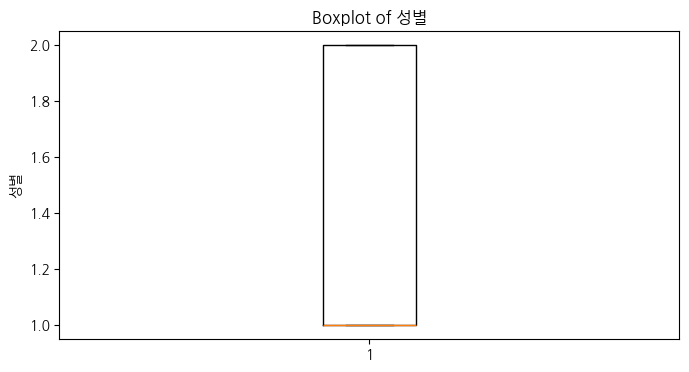

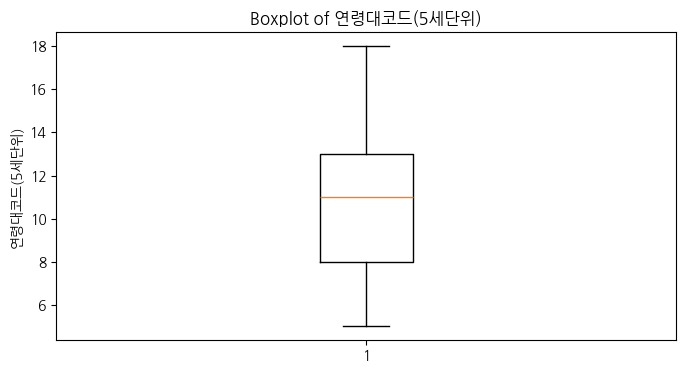

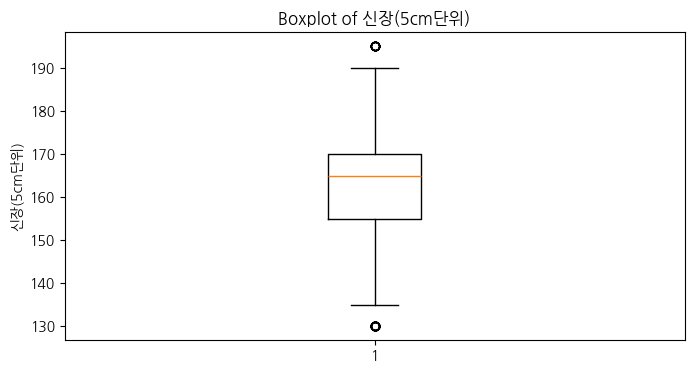

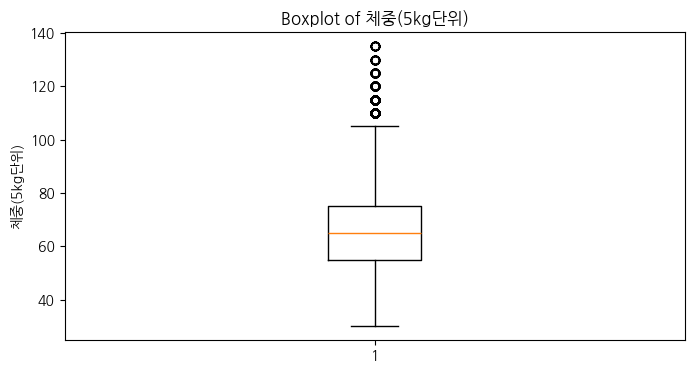

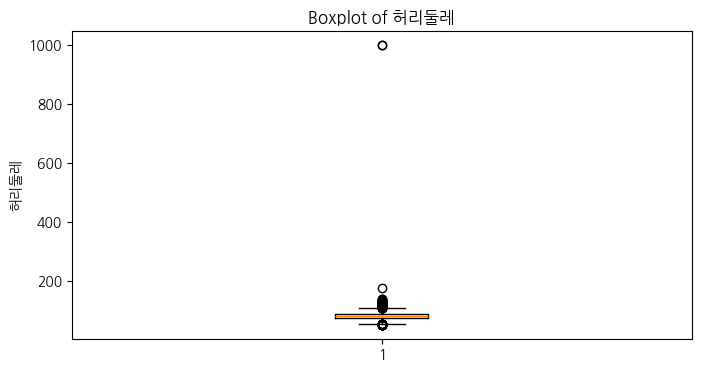

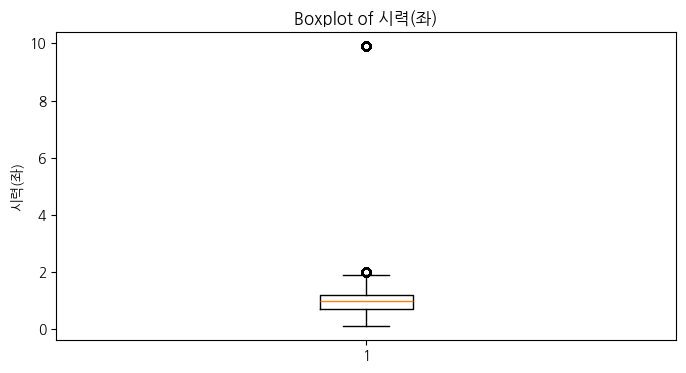

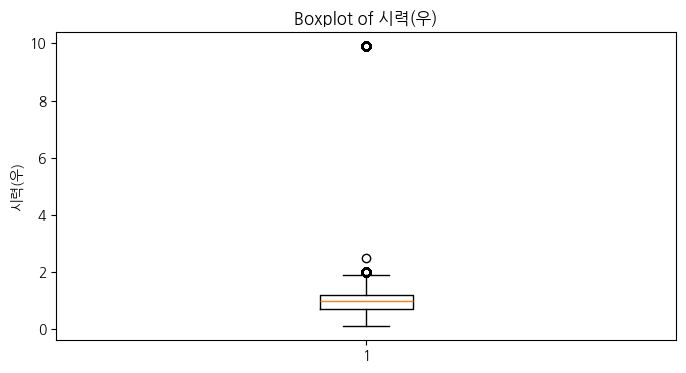

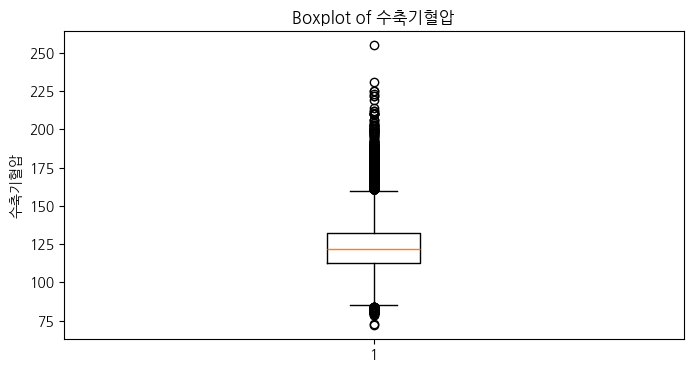

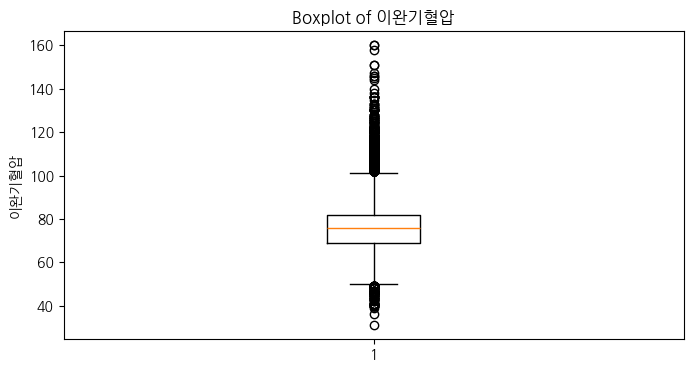

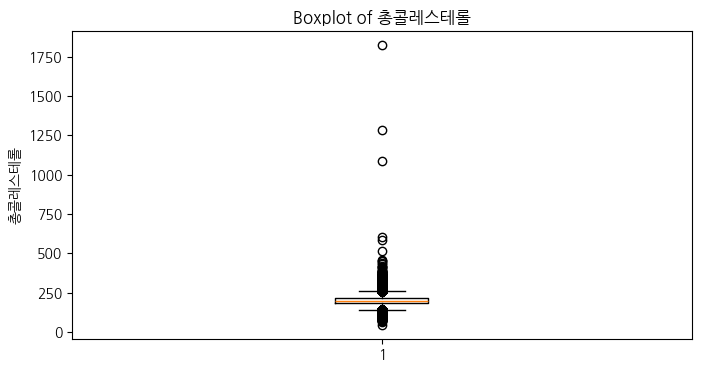

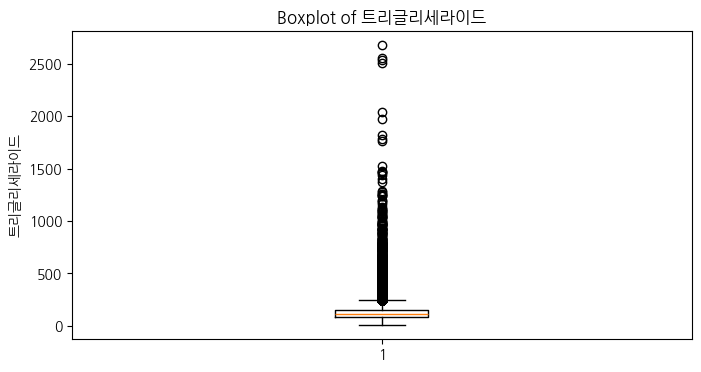

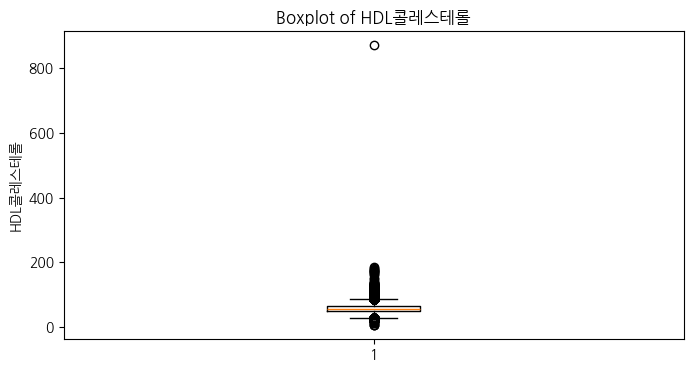

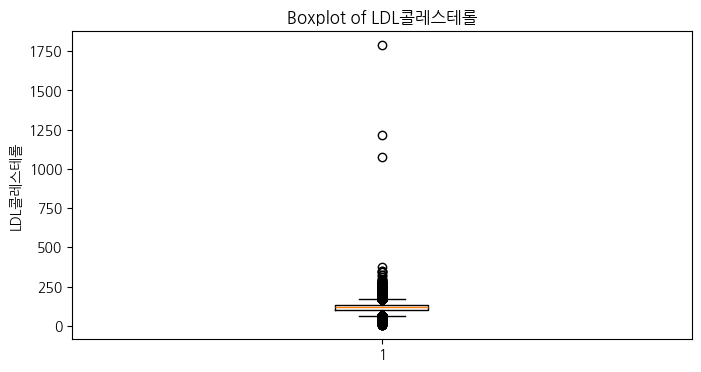

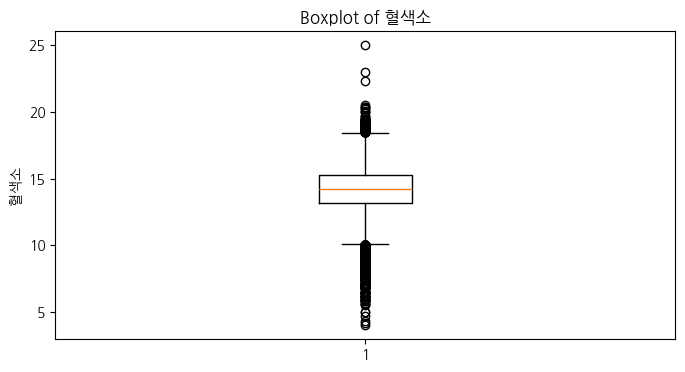

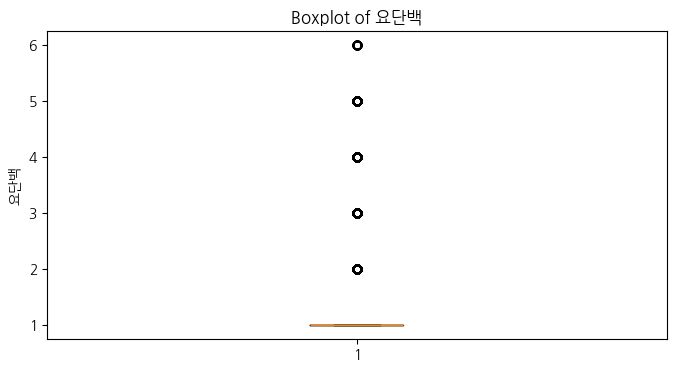

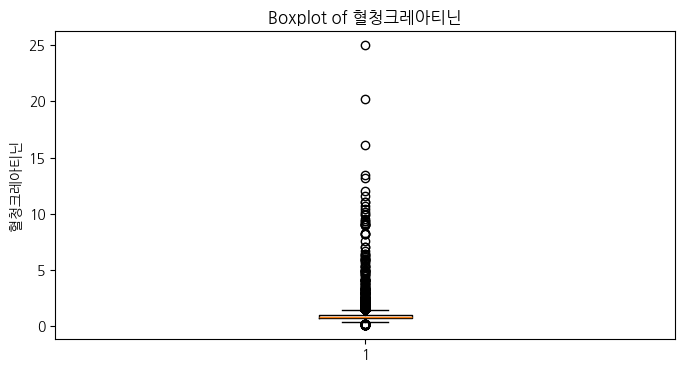

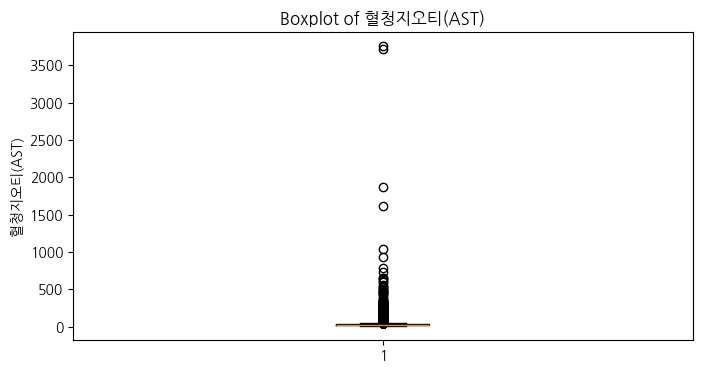

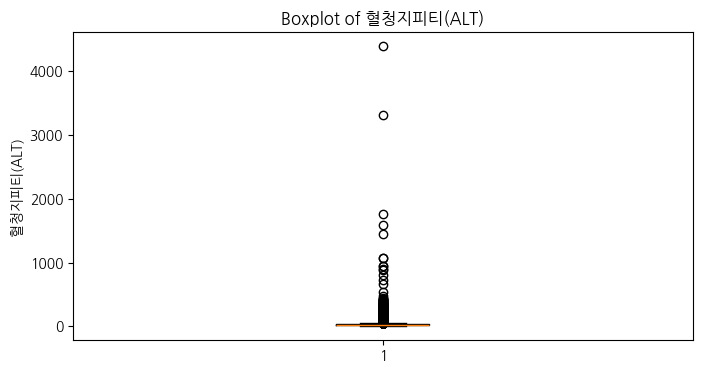

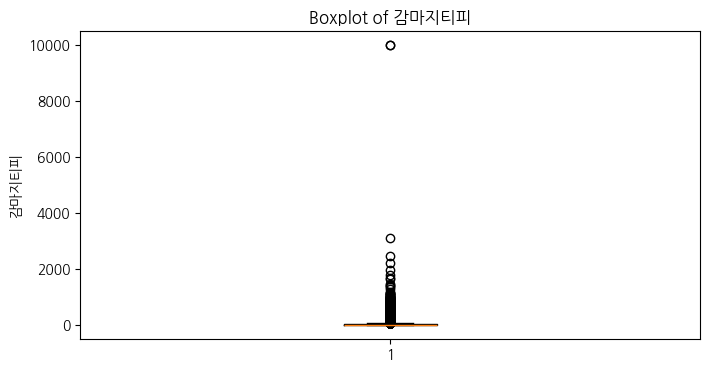

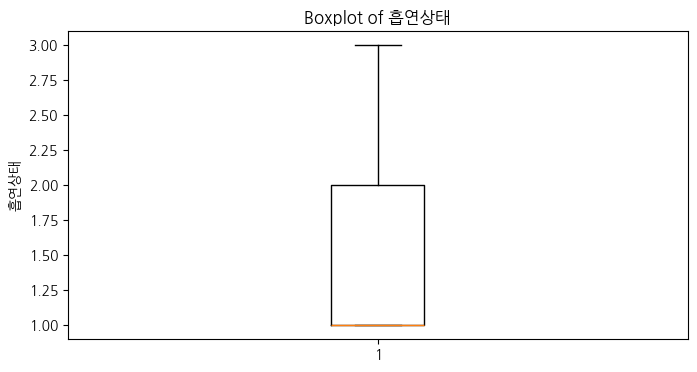

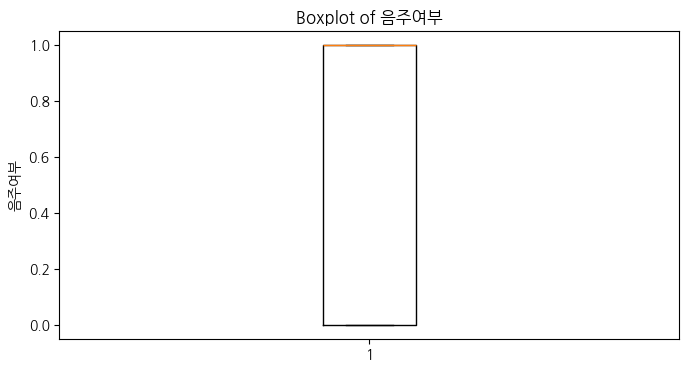

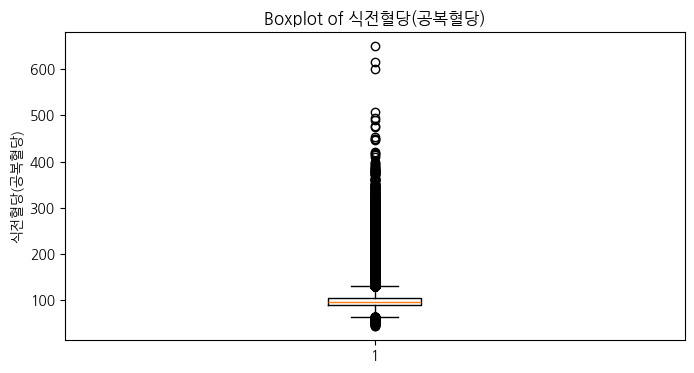

In [137]:
import koreanize_matplotlib

for col in df_result.columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_result[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [138]:
cond = df_result['허리둘레'] > 600
df_result[cond]

,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),수축기혈압,이완기혈압,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,식전혈당(공복혈당)
23513,2,8,155,45.0,999.0,0.8,0.8,111.0,71.0,201.568962,145.845756,53.150997,118.848814,13.7,1.0,0.4,16.0,11.0,12.0,1.0,0.0,81.0
25610,2,7,160,75.0,999.0,1.0,1.0,106.0,62.0,201.566085,145.837286,53.154416,118.844169,11.1,1.0,0.6,15.0,15.0,12.0,1.0,0.0,90.0


In [139]:
# 허리둘레 이상치 값 제거
df_result = df_result[~cond].reset_index(drop=True)

print(df_result.shape)
print(df_result['허리둘레'].max())

(98788, 22)
177.0


In [140]:
df_result['식전혈당(공복혈당)'].describe()

count    98788.000000
mean       101.050816
std         23.756542
min         44.000000
25%         89.000000
50%         96.000000
75%        106.000000
max        649.000000
Name: 식전혈당(공복혈당), dtype: float64

In [141]:
# 식전혈당이 649인 것은 사실상 말이 안되는 이상치 -> 상한가를 300으로 잡고 이상치 drop하자
df_result['식전혈당(공복혈당)'] = df_result['식전혈당(공복혈당)'].clip(upper=300)

df_result['식전혈당(공복혈당)'].describe()

count    98788.000000
mean       100.970361
std         22.869815
min         44.000000
25%         89.000000
50%         96.000000
75%        106.000000
max        300.000000
Name: 식전혈당(공복혈당), dtype: float64

### 변수 분포 시각화

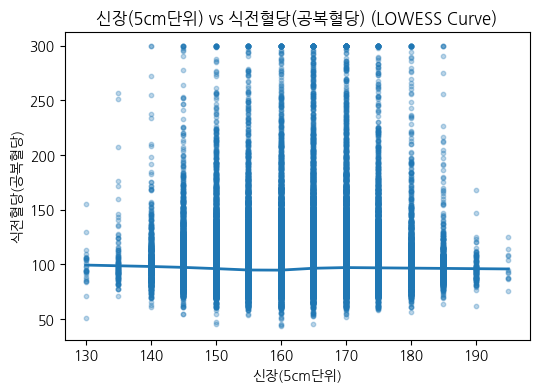

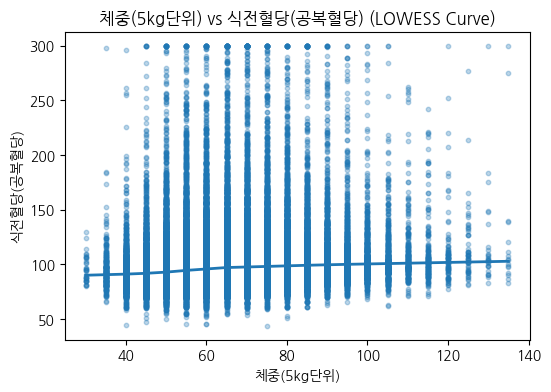

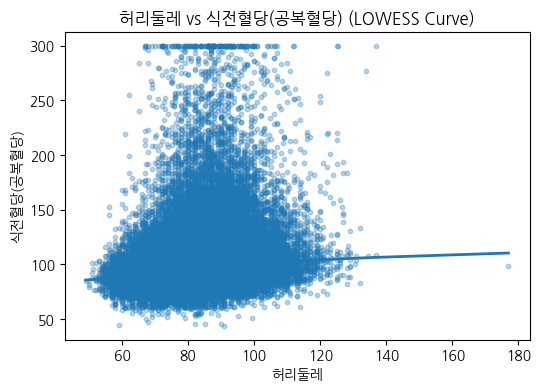

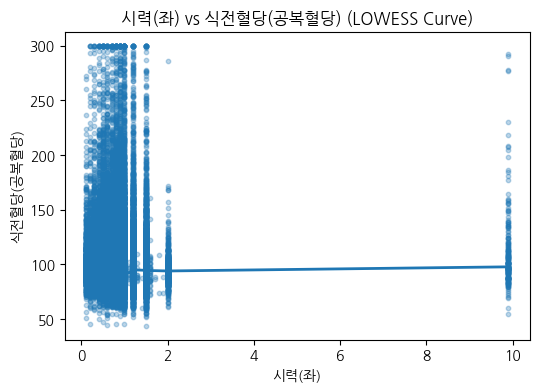

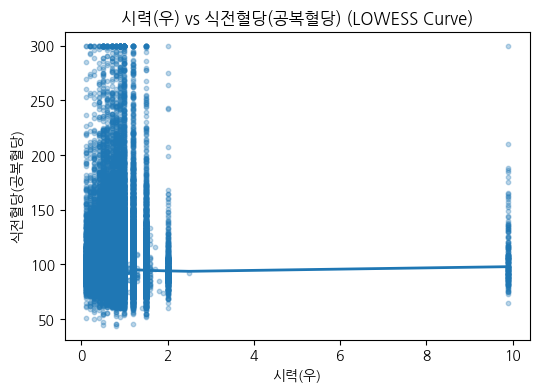

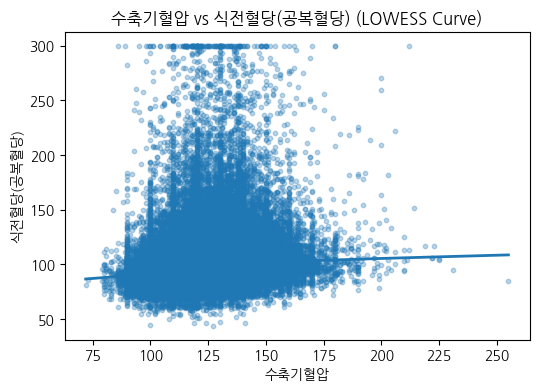

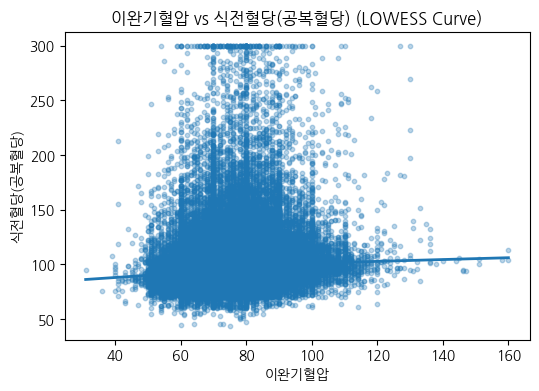

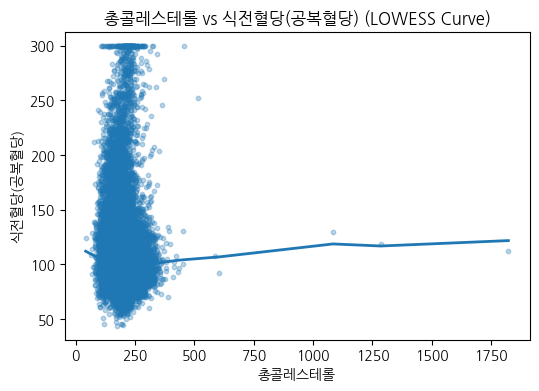

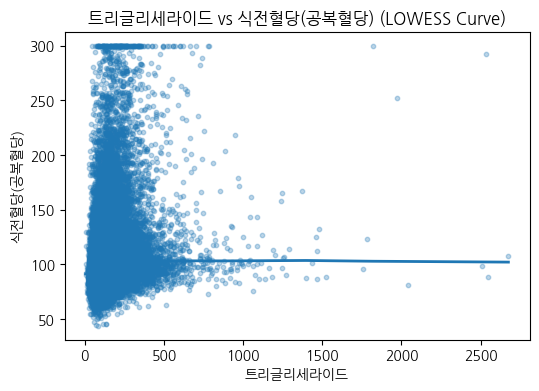

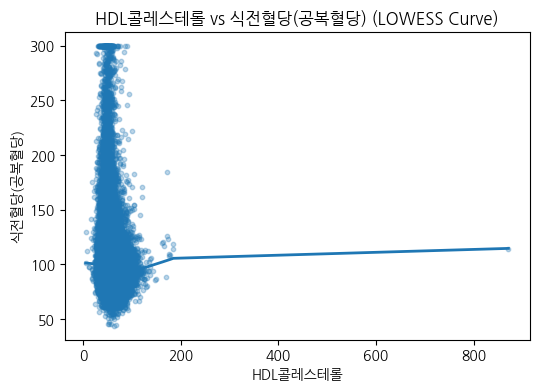

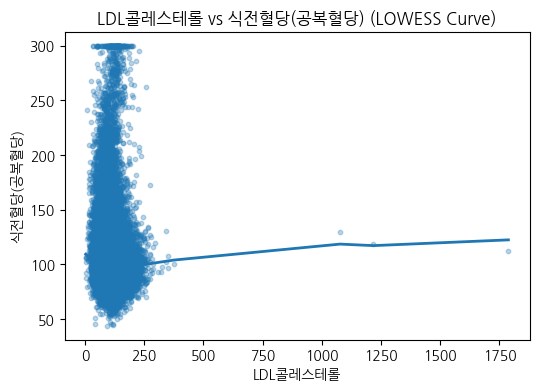

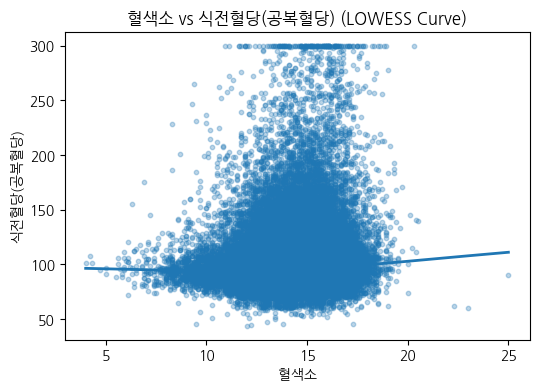

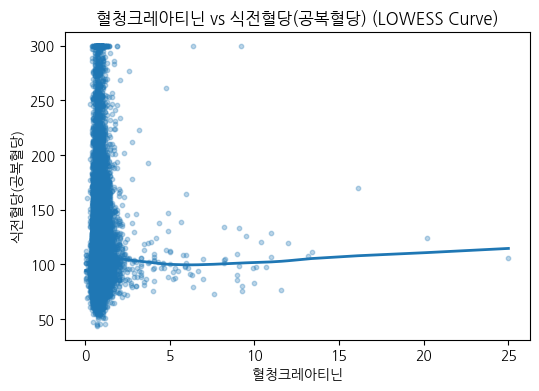

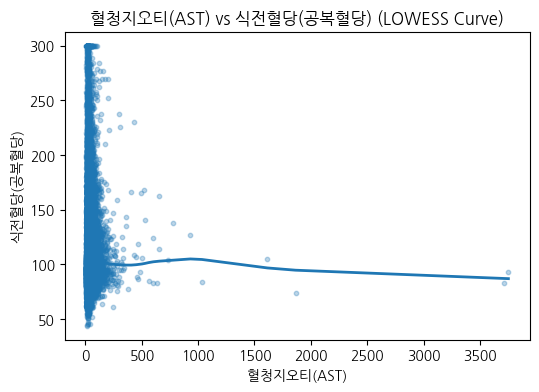

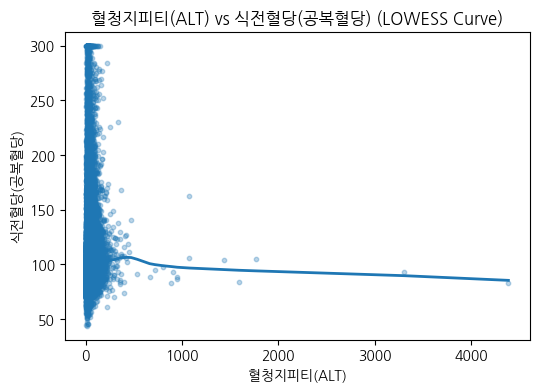

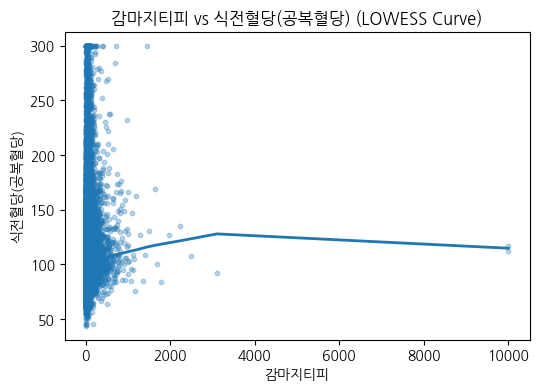

In [142]:
from statsmodels.nonparametric.smoothers_lowess import lowess

target = '식전혈당(공복혈당)'

feature_cols = ['신장(5cm단위)', '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '수축기혈압', '이완기혈압', 
            '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소',
            '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피']

for col in feature_cols:
    x = df_result[col].values
    y = df_result[target].values

    smooth = lowess(y, x, frac=0.3)

    plt.figure(figsize=(6,4))
    plt.scatter(x, y, alpha=0.3, s=10)
    plt.plot(smooth[:, 0], smooth[:, 1], linewidth=2)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target} (LOWESS Curve)")
    plt.show()

### Right Skew 된 변수들 Log 변환

In [143]:
log_cols = [
    '총콜레스테롤',
    '트리글리세라이드',
    'HDL콜레스테롤',
    'LDL콜레스테롤',
    '혈청크레아티닌',
    '혈청지오티(AST)',
    '혈청지피티(ALT)',
    '감마지티피'
]

for col in log_cols:
    df_result[col] = np.log1p(df_result[col])

df_result.head()

,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),수축기혈압,이완기혈압,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,식전혈당(공복혈당)
0,1,16,160,45.0,70.3,0.7,0.7,124.0,68.0,5.164786,3.806662,4.564348,4.262680,12.9,1.0,0.587787,3.218876,2.944439,3.367296,2.0,0.0,99.0
1,2,7,155,50.0,66.0,1.2,1.5,113.0,67.0,5.236809,3.878513,4.291317,4.677742,12.4,1.0,0.587787,3.091042,2.302585,2.397895,1.0,1.0,73.0
2,1,6,180,95.0,96.3,1.0,1.2,130.0,80.0,5.314954,5.439971,3.914293,4.597614,14.5,1.0,0.741937,3.713572,4.248495,4.477337,1.0,0.0,103.0
3,2,13,155,55.0,70.5,1.2,0.7,106.0,62.0,5.367148,4.323861,4.367054,4.798552,14.1,1.0,0.693147,3.433987,2.995732,2.484907,1.0,1.0,84.0
4,1,10,155,65.0,87.0,9.9,1.0,138.0,86.0,5.329631,4.625315,4.084305,4.848991,14.6,1.0,0.587787,2.995732,2.944439,3.044522,3.0,1.0,105.0


**다시 시각화**

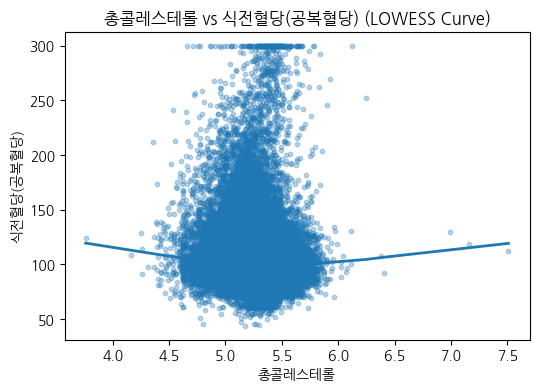

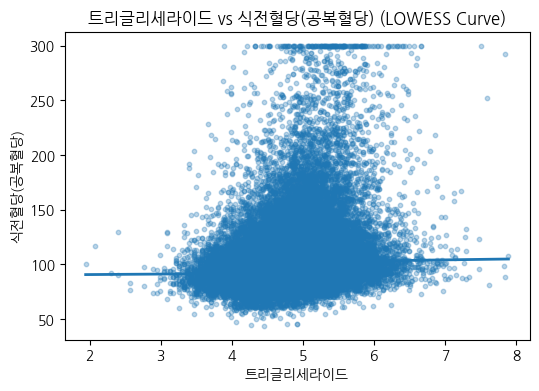

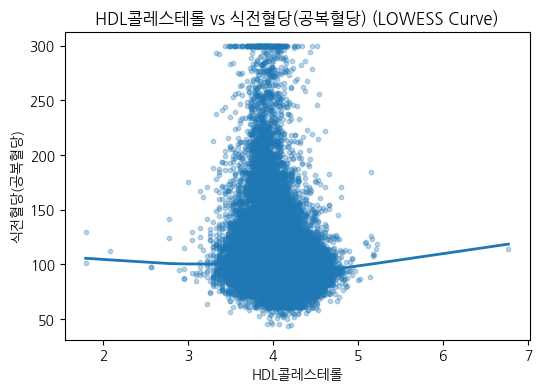

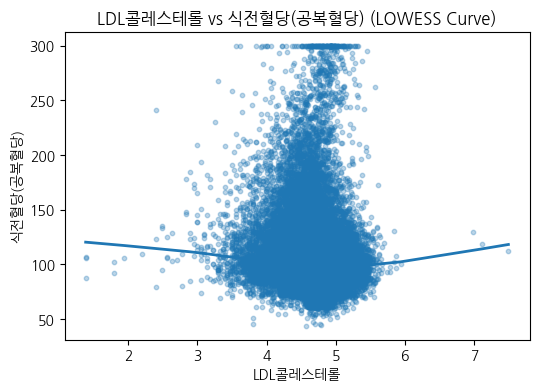

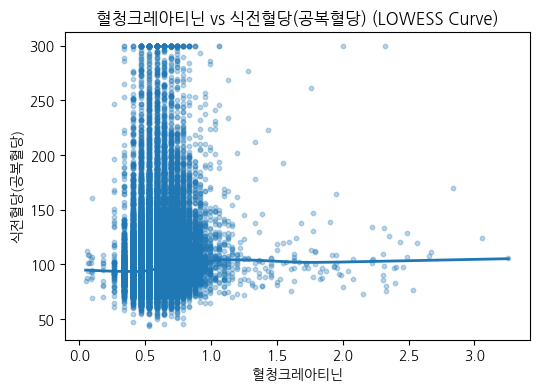

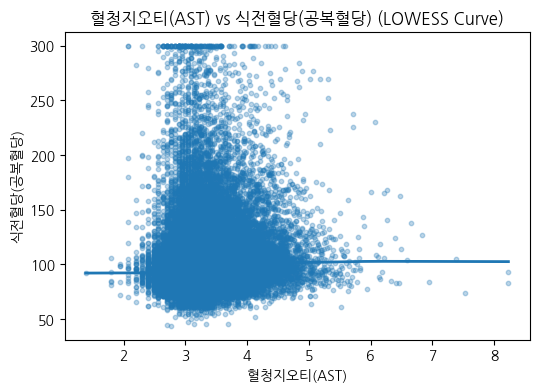

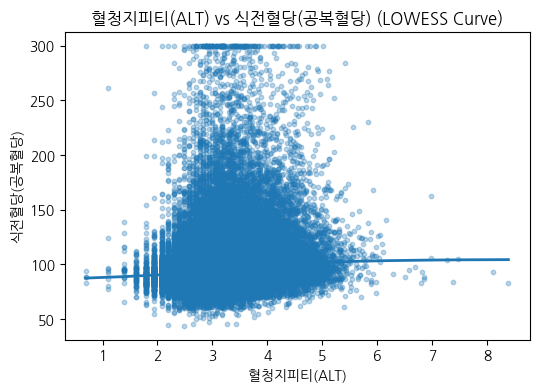

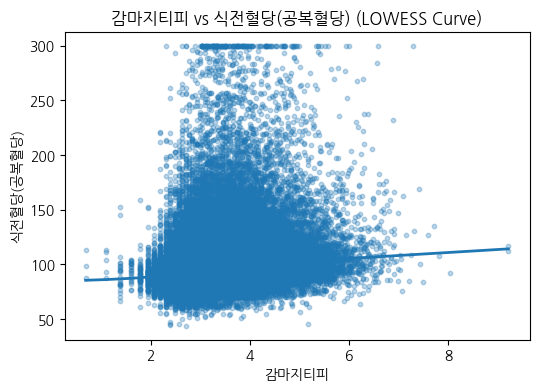

In [144]:
from statsmodels.nonparametric.smoothers_lowess import lowess

target = '식전혈당(공복혈당)'

log_feature_cols = ['총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤',
            '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피']

for col in log_feature_cols:
    x = df_result[col].values
    y = df_result[target].values

    smooth = lowess(y, x, frac=0.3)

    plt.figure(figsize=(6,4))
    plt.scatter(x, y, alpha=0.3, s=10)
    plt.plot(smooth[:, 0], smooth[:, 1], linewidth=2)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target} (LOWESS Curve)")
    plt.show()

### Robust 정규화

In [146]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_scaled = df_result.copy()

df_scaled[feature_cols] = scaler.fit_transform(df_result[feature_cols])

df_scaled.head()

,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),수축기혈압,이완기혈압,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,식전혈당(공복혈당)
0,1,16,-0.333333,-1.00,-0.764286,-0.6,-0.6,0.105263,-0.615385,-0.893931,-1.655260,2.101394,-2.200353,-0.619048,1.0,0.000000,0.093147,-0.211504,0.212399,2.0,0.0,99.0
1,2,7,-0.666667,-0.75,-1.071429,0.4,1.0,-0.473684,-0.692308,-0.413814,-1.526088,0.975777,-0.402042,-0.857143,1.0,0.000000,-0.198541,-1.137504,-0.875625,1.0,1.0,73.0
2,1,6,1.000000,1.50,1.092857,0.0,0.4,0.421053,0.307692,0.107120,1.281067,-0.578563,-0.749207,0.142857,1.0,0.948509,1.221933,1.669851,1.458274,1.0,0.0,103.0
3,2,13,-0.666667,-0.50,-0.750000,0.4,-0.6,-0.842105,-1.076923,0.455055,-0.725451,1.288017,0.121383,-0.047619,1.0,0.648297,0.583983,-0.137504,-0.777967,1.0,1.0,84.0
4,1,10,-0.666667,0.00,0.428571,17.8,0.0,0.842105,0.769231,0.204960,-0.183504,0.122338,0.339917,0.190476,1.0,0.000000,-0.416017,-0.211504,-0.149871,3.0,1.0,105.0


### 상관관계

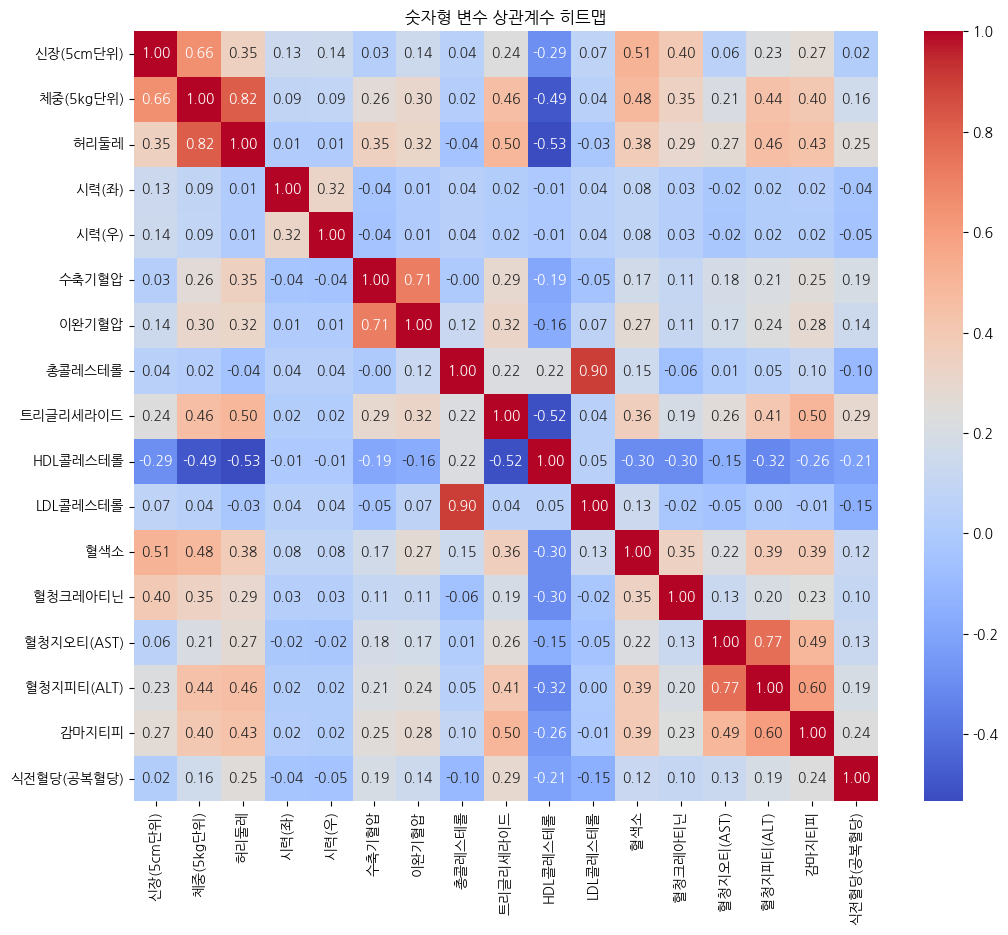

In [147]:
import seaborn as sns

num_cols = ['신장(5cm단위)', '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '수축기혈압', '이완기혈압',
            '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소',
            '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '식전혈당(공복혈당)']
corr_matrix = df_scaled[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("숫자형 변수 상관계수 히트맵")
plt.show()

> 상관계수 히트맵 분석

    1. 허리둘레와 식전혈당(공복혈당) : 0.25
    2. 트리글리세라이드와 식전혈당(공복혈당) : 0.29
    3. 체중(5kg단위)와 식전혈당(공복혈당) : 0.16
    4. 수축기혈압과 식전혈당(공복혈당) : 0.19
    5. 이완기혈압과 식전혈당(공복혈당) : 0.14
    6. HDL콜레스테롤과 식전혈당(공복혈당) : -0.21
    7. LDL콜레스테롤과 식전혈당(공복혈당) : -0.15
    8. 혈청지피티(ALT)과 식전혈당(공복혈당) : 0.19
    9. 감마지티피와 식전혈당(공복혈당) : 0.24

> 허리둘레와 상관성이 높은 변수 : 체중(0.82), 신장(0.35), 수축기혈압(0.35), 이완기혈압(0.32), 트리글리세라이드(0.50), HDL콜레스테롤(-0.53), 혈색소(0.38), 혈청지피티_ALT(0.46), 감마지티피(0.43)

> 신장&체중 (0.66), 체중&허리둘레(0.82), 수축기혈압&이완기혈압(0.71), 총콜레스테롤&LDL콜레스테롤(0.90), 혈청지오티(AST)&혈청지피티(ALT) (0.77), 혈청지피티(ALT)&감마지티피 (0.60) 간의 강한 상관관계를 가짐

In [148]:
df_result = df_scaled.copy()

In [149]:
df_result.columns

Index(['성별', '연령대코드(5세단위)', '신장(5cm단위)', '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)',
       '수축기혈압', '이완기혈압', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소',
       '요단백', '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부',
       '식전혈당(공복혈당)'],
      dtype='object')

### 범주형 변수 간 카이제곱 검정

- 범주형 변수와 식전혈당(공복혈당)과의 관계성 분석을 위해 구간화 한 새로운 컬럼 생성

In [150]:
df_result['FBG_cat'] = pd.cut(
    df_result['식전혈당(공복혈당)'],
    bins = [0, 99, 125, 300], # 대한당뇨학회 기준 (100미만 정상 : 0, 100~125 공복혈당장애 : 1, 125이상 당뇨 : 2)
    labels=[0, 1, 2]
)

df_result.head()

,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),수축기혈압,이완기혈압,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,식전혈당(공복혈당),FBG_cat
0,1,16,-0.333333,-1.00,-0.764286,-0.6,-0.6,0.105263,-0.615385,-0.893931,-1.655260,2.101394,-2.200353,-0.619048,1.0,0.000000,0.093147,-0.211504,0.212399,2.0,0.0,99.0,0
1,2,7,-0.666667,-0.75,-1.071429,0.4,1.0,-0.473684,-0.692308,-0.413814,-1.526088,0.975777,-0.402042,-0.857143,1.0,0.000000,-0.198541,-1.137504,-0.875625,1.0,1.0,73.0,0
2,1,6,1.000000,1.50,1.092857,0.0,0.4,0.421053,0.307692,0.107120,1.281067,-0.578563,-0.749207,0.142857,1.0,0.948509,1.221933,1.669851,1.458274,1.0,0.0,103.0,1
3,2,13,-0.666667,-0.50,-0.750000,0.4,-0.6,-0.842105,-1.076923,0.455055,-0.725451,1.288017,0.121383,-0.047619,1.0,0.648297,0.583983,-0.137504,-0.777967,1.0,1.0,84.0,0
4,1,10,-0.666667,0.00,0.428571,17.8,0.0,0.842105,0.769231,0.204960,-0.183504,0.122338,0.339917,0.190476,1.0,0.000000,-0.416017,-0.211504,-0.149871,3.0,1.0,105.0,1


In [151]:
from scipy.stats import chi2_contingency

cat_cols = ['성별', '흡연상태', '음주여부', '연령대코드(5세단위)', '요단백']

for col in cat_cols:
    contingency_table = pd.crosstab(df_result[col], df_result['FBG_cat'])
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    print(f"-----{col}-----")
    print(contingency_table)
    print(f"chi2={chi2:.2f}, p-value={p:.4f}, dof={dof}\n")

-----성별-----
FBG_cat      0      1     2
성별                         
1        27554  18559  5172
2        32007  12754  2742
chi2=2013.38, p-value=0.0000, dof=2

-----흡연상태-----
FBG_cat      0      1     2
흡연상태                       
1.0      40894  18294  4130
2.0       8354   6408  1760
3.0      10313   6611  2024
chi2=1528.67, p-value=0.0000, dof=4

-----음주여부-----
FBG_cat      0      1     2
음주여부                       
0.0      19648  10925  3215
1.0      39913  20388  4699
chi2=190.63, p-value=0.0000, dof=2

-----연령대코드(5세단위)-----
FBG_cat         0     1     2
연령대코드(5세단위)                  
5            3033   426    32
6            5895  1074    63
7            6792  1861   181
8            5265  1981   276
9            7741  3415   614
10           5894  3163   710
11           7162  4422  1109
12           4817  3760  1089
13           5412  4383  1418
14           3050  2568   865
15           2494  2291   841
16            986  1022   367
17            807   726   296
18         

비율로서 각 순서형 범주 값과 타겟 값 간의 관계 파악

In [152]:
cat_cols = ['연령대코드(5세단위)', '요단백']

for col in cat_cols:
    contingency_table = pd.crosstab(df_result[col], df_result['FBG_cat'])
    row_percent = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

    print(f"------{col} (행 기준 비율, %)------")
    print(row_percent.round(2))
    print("\n")

------연령대코드(5세단위) (행 기준 비율, %)------
FBG_cat          0      1      2
연령대코드(5세단위)                     
5            86.88  12.20   0.92
6            83.83  15.27   0.90
7            76.88  21.07   2.05
8            69.99  26.34   3.67
9            65.77  29.01   5.22
10           60.35  32.38   7.27
11           56.42  34.84   8.74
12           49.83  38.90  11.27
13           48.27  39.09  12.65
14           47.05  39.61  13.34
15           44.33  40.72  14.95
16           41.52  43.03  15.45
17           44.12  39.69  16.18
18           43.74  45.38  10.88


------요단백 (행 기준 비율, %)------
FBG_cat      0      1      2
요단백                         
1.0      60.89  31.73   7.38
2.0      59.22  30.12  10.66
3.0      49.29  32.85  17.86
4.0      37.76  34.59  27.64
5.0      35.16  31.96  32.88
6.0      41.38  24.14  34.48




## 회귀 모델

### linearRegression (단일 회귀 모델)

- 허리둘레로만 이루어진 모델이 이루어질 경우 해당 모델의 설명력이 어느 정도인지 파악하기 위함

In [153]:
import statsmodels.api as sm

x = df_result[['허리둘레']]
y = df_result[['식전혈당(공복혈당)']]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             식전혈당(공복혈당)   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     6635.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:28:47   Log-Likelihood:            -4.4615e+05
No. Observations:               98788   AIC:                         8.923e+05
Df Residuals:                   98786   BIC:                         8.923e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.7240      0.071   1428.688      0.0

- 허리둘레가 1단위 증가할 때 식전혈당이 7.5987 만큼 증가한다.
- 허리둘레의 p-value = 0 < 0.05이므로 허리둘레는 통계적으로 유의미한 변수라고 파악할 수 있다.
    - 즉 허리둘레가 증가할 때 식전혈당이 증가하는 것이 우연이 아니다.
- 허리둘레의 신뢰구간은 [0.025, 0.975]로 허리둘레가 혈당에 미치는 영향이 95% 신뢰수준에서 해당 구간 사이에 있을 것이라는 의미이다.
- 해당 모델의 설명력을 나타내는 R^2 값이 0.063으로 허리둘레가 유의미한 변수는 맞지만 허리둘레 변수만으로 식전혈당을 설명하기에는 부족함을 파악할 수 있다.

**따라서 모델의 설명력을 높이기 위해, 전진 선택법으로 설명력이 높은 변수를 하나씩 추가해 가는 방식을 사용한다.**

In [154]:
df_result = df_result.rename(columns={'연령대코드(5세단위)':'연령대코드_5세단위',
                                      '신장(5cm단위)':'신장_5cm단위',
                                      '체중(5kg단위)':'체중_5kg단위',
                                      '시력(좌)':'시력_좌', '시력(우)':'시력_우',
                                      '혈청지오티(AST)':'혈청지오티_AST',
                                      '혈청지피티(ALT)':'혈청지피티_ALT',
                                      '식전혈당(공복혈당)':'식전혈당_공복혈당'})

In [155]:
df_fin = df_result.drop(columns={'FBG_cat'})
df_fin.head()

,성별,연령대코드_5세단위,신장_5cm단위,체중_5kg단위,허리둘레,시력_좌,시력_우,수축기혈압,이완기혈압,총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티_AST,혈청지피티_ALT,감마지티피,흡연상태,음주여부,식전혈당_공복혈당
0,1,16,-0.333333,-1.00,-0.764286,-0.6,-0.6,0.105263,-0.615385,-0.893931,-1.655260,2.101394,-2.200353,-0.619048,1.0,0.000000,0.093147,-0.211504,0.212399,2.0,0.0,99.0
1,2,7,-0.666667,-0.75,-1.071429,0.4,1.0,-0.473684,-0.692308,-0.413814,-1.526088,0.975777,-0.402042,-0.857143,1.0,0.000000,-0.198541,-1.137504,-0.875625,1.0,1.0,73.0
2,1,6,1.000000,1.50,1.092857,0.0,0.4,0.421053,0.307692,0.107120,1.281067,-0.578563,-0.749207,0.142857,1.0,0.948509,1.221933,1.669851,1.458274,1.0,0.0,103.0
3,2,13,-0.666667,-0.50,-0.750000,0.4,-0.6,-0.842105,-1.076923,0.455055,-0.725451,1.288017,0.121383,-0.047619,1.0,0.648297,0.583983,-0.137504,-0.777967,1.0,1.0,84.0
4,1,10,-0.666667,0.00,0.428571,17.8,0.0,0.842105,0.769231,0.204960,-0.183504,0.122338,0.339917,0.190476,1.0,0.000000,-0.416017,-0.211504,-0.149871,3.0,1.0,105.0


### AIC, BIC 기반의 다중 회귀 모델

🚨 코드 작성에 있어서 생성형 AI를 활용하였습니다.

In [ ]:
from statsmodels.formula.api import ols

def forward_selection(data, target, candidates, categorical=[], criterion='aic'):
    remaining = candidates.copy()
    selected = []
    current_score = float('inf')
    best_model = None

    def make_formula(cols):
        terms = []
        for col in cols:
            if col in categorical:
                terms.append(f"C({col})")
            else:
                terms.append(col)
        formula = f"{target} ~ " + " + ".join(terms) if terms else f"{target} ~ 1"
        return formula

    while remaining:
        scores_with_candidates = []
        for col in remaining:
            formula = make_formula(selected + [col])
            model = ols(formula, data=data).fit()
            score = model.aic if criterion=='aic' else model.bic
            scores_with_candidates.append((score, col, model))
        
        # 가장 AIC/BIC가 낮은 변수 선택
        scores_with_candidates.sort()
        best_score, best_candidate, best_candidate_model = scores_with_candidates[0]

        if best_score < current_score:
            selected.append(best_candidate)
            remaining.remove(best_candidate)
            current_score = best_score
            best_model = best_candidate_model
            print(f"\n변수 추가: {best_candidate}")
            print(f"AIC: {best_score:.2f}")
            print(best_model.summary())
        else:
            break

    return best_model, selected

# 사용 예시
target = '식전혈당_공복혈당'
all_vars = ['성별', '연령대코드_5세단위', '신장_5cm단위', '체중_5kg단위', '허리둘레', '시력_좌', '시력_우',
       '수축기혈압', '이완기혈압', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소',
       '요단백', '혈청크레아티닌', '혈청지오티_AST', '혈청지피티_ALT', '감마지티피', '흡연상태', '음주여부']

categorical_vars = ['음주여부','흡연상태','성별']

final_model, final_vars = forward_selection(df_fin, target=target, 
                                            candidates=all_vars, 
                                            categorical=categorical_vars,
                                            criterion='aic')

print("\n최종 선택 변수:", final_vars)
print(final_model.summary())



변수 추가: 트리글리세라이드
AIC: 890058.58
                            OLS Regression Results                            
Dep. Variable:              식전혈당_공복혈당   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     9061.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:29:50   Log-Likelihood:            -4.4503e+05
No. Observations:               98788   AIC:                         8.901e+05
Df Residuals:                   98786   BIC:                         8.901e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    100.586

- 해당 모델의 R-squared = 0.172로 모델은 식전혈당(공복혈당) 값을 약 17.2% 정도 설명할 수 있다.
- 해당 모델에 포함된 변수들은 '트리글리세라이드', '연령대코드_5세단위', '총콜레스테롤', '감마지티피', '요단백', '허리둘레', 'LDL콜레스테롤', '혈청지오티_AST', '혈청지피티_ALT', '수축기혈압', 'HDL콜레스테롤', '성별', '혈색소', '시력_우', '시력_좌', '흡연상태', '혈청크레아티닌'이다.
- F-statistic = 1142, Prob(F) = 0.00으로 독립변수 집합이 통계적으로 유의하게 종속변수를 설명한다. -‘트리글리세라이드’, ‘요단백’, ‘감마지티피’, ‘혈청지피티(ALT)’, ‘허리둘레’, ‘연령대코드(5세단위)’, ‘수축기혈압’,‘혈색소’ 컬럼들은 혈당 증가의 요인으로 식전혈당(공복혈당)과 양의 선형관계를 가진다.
- ‘LDL콜레스테롤’, ‘HDL콜레스테롤’, ‘혈청지오티(AST)’, ‘시력(좌)’, ‘시력(우)’ 컬럼들은 식전혈당(공복혈당)과 음의 선형관계를 가진다.